In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
file = "/content/drive/MyDrive/tips.csv"
df = pd.read_csv(file)
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
print("Shape of the data:", df.shape)



Shape of the data: (244, 7)


In [ ]:
print("Columns", df.columns)

Columns Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [ ]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [ ]:
df = df.drop_duplicates()

In [ ]:
numeric_cols = ['total_bill', 'tip','size']
for col in numeric_cols:
  df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
for col in numeric_cols:
  df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-3157075709.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
#Highest bill according to day
revenue_day = df[['day', 'total_bill']].sort_values(by='total_bill', ascending=False)
print("Revenue")
print(revenue_day.head())

Revenue
     day  total_bill
170  Sat       50.81
212  Sat       48.33
59   Sat       48.27
156  Sun       48.17
182  Sun       45.35


In [ ]:
revenue_time = df[['time', 'total_bill']].sort_values(by='total_bill', ascending=False)
print("Revenue")
print(revenue_time.head())

Revenue
       time  total_bill
170  Dinner       50.81
212  Dinner       48.33
59   Dinner       48.27
156  Dinner       48.17
182  Dinner       45.35


In [ ]:
#Total revenue by day
revenue_day = df.groupby('day')['total_bill'].sum().sort_values(ascending=False)
print("Revenue by day")
print(revenue_day)

Revenue by day
day
Sat     1778.40
Sun     1627.16
Thur    1083.33
Fri      325.88
Name: total_bill, dtype: float64


In [ ]:
#Total revenue by time
revenue_time = df.groupby('time')['total_bill'].sum()
print("Total revenue by Time")
print(revenue_time)

Total revenue by Time
time
Dinner    3660.30
Lunch     1154.47
Name: total_bill, dtype: float64


In [ ]:
#Average bill by the day
avg_bill_day = df.groupby('day')['total_bill'].mean().sort_values(ascending=False)
print("Average bill by day")
print(avg_bill_day)

Average bill by day
day
Sun     21.410000
Sat     20.441379
Thur    17.759508
Fri     17.151579
Name: total_bill, dtype: float64


In [ ]:
#Average bill time
avg_bill_time = df.groupby('time')['total_bill'].mean().sort_values(ascending=False)
print("Average bill by time")
print(avg_bill_time)

Average bill by time
time
Dinner    20.797159
Lunch     17.230896
Name: total_bill, dtype: float64


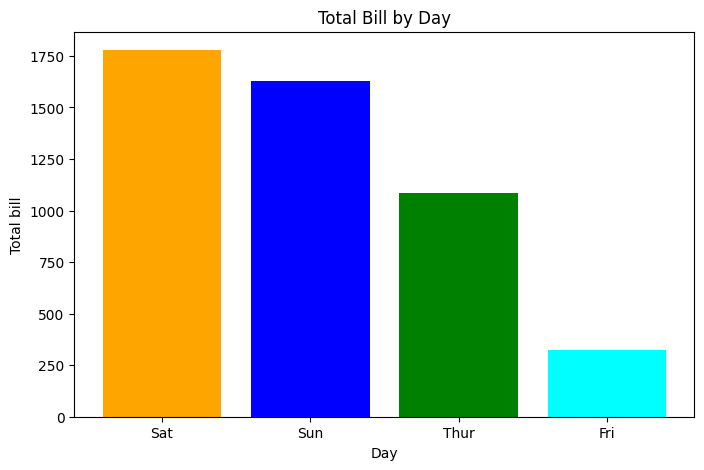

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(revenue_day.index, revenue_day.values, color=['Orange','Blue','Green','Cyan'])
plt.title("Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Total bill")
plt.show()

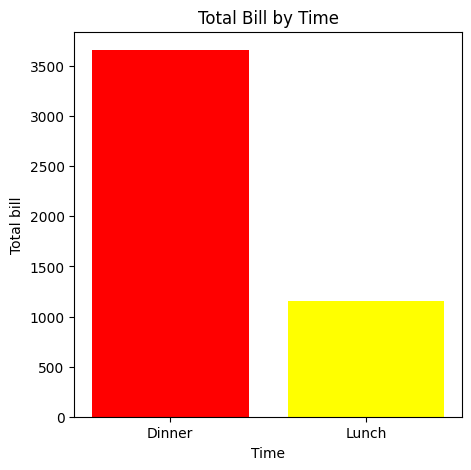

In [ ]:
plt.figure(figsize=(5,5))
plt.bar(revenue_time.index, revenue_time.values, color=['Red', 'Yellow'])
plt.title("Total Bill by Time")
plt.xlabel("Time")
plt.ylabel("Total bill")
plt.show()

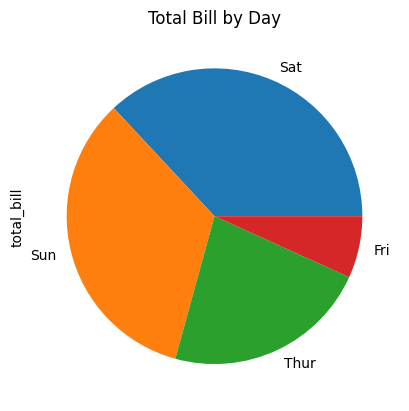

In [ ]:
revenue_day.plot(kind= 'pie', color=['Orange','Blue','Green','Cyan'])
plt.title("Total Bill by Day")
plt.show()